# Notebook 01 — Data Generation
**AIRI: AI Readiness Index for UK Debt Management Institutions**

**Purpose:** Generate the synthetic dataset of 150 UK debt management institutions, explore its statistical properties, validate distributions and correlations, and export `data/synthetic_institutions.csv` for downstream scoring.

---

## Imports & Global Seed

In [1]:
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Global seed — must be set here before any other code
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Path setup — run from project root (airi_proj/) 
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

# ── Plot styling 
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 100,
})
sns.set_style('whitegrid')
PALETTE = ['#1B3A6B', '#0D6E8A', '#059669', '#D97706', '#DC2626']

print(f'Python  : {sys.version.split()[0]}')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Project root: {PROJECT_ROOT}')
print('Seed set: 42')

Python  : 3.8.10
Pandas  : 2.0.3
NumPy   : 1.24.4
Project root: /Users/bukunmi/Documents/myprojects/AIRI_PROJ
Seed set: 42


## Generate Synthetic Dataset

In [2]:
from src.data_generator import generate_synthetic_institutions, INDICATORS

OUTPUT_PATH = PROJECT_ROOT / 'data' / 'synthetic_institutions.csv'

df = generate_synthetic_institutions(
    output_path=str(OUTPUT_PATH),
    seed=RANDOM_SEED,
)

print(f'Generated : {len(df)} institutions')
print(f'Columns   : {len(df.columns)}')
print(f'Saved to  : {OUTPUT_PATH}')
print(f'File exists: {OUTPUT_PATH.exists()}')

Generated : 150 institutions
Columns   : 19
Saved to  : /Users/bukunmi/Documents/myprojects/AIRI_PROJ/data/synthetic_institutions.csv
File exists: True


## Dataset Overview

In [3]:
print('=== SHAPE ===')
print(f'{df.shape[0]} rows × {df.shape[1]} columns')
print()
print('=== COLUMN TYPES ===')
print(df.dtypes.to_string())
print()
print('=== FIRST 5 ROWS ===')
df.head()

=== SHAPE ===
150 rows × 19 columns

=== COLUMN TYPES ===
institution_id               object
institution_name             object
sector                       object
institution_size             object
data_quality                  int64
data_governance               int64
data_integration              int64
system_capability             int64
ai_tooling                    int64
infrastructure_resilience     int64
fca_alignment                 int64
consumer_duty                 int64
audit_trail                   int64
talent_readiness              int64
change_management             int64
leadership_commitment         int64
bias_mitigation               int64
explainability                int64
accountability_structures     int64

=== FIRST 5 ROWS ===


,institution_id,institution_name,sector,institution_size,data_quality,data_governance,data_integration,system_capability,ai_tooling,infrastructure_resilience,fca_alignment,consumer_duty,audit_trail,talent_readiness,change_management,leadership_commitment,bias_mitigation,explainability,accountability_structures
0,INST_001,McLean Financial Services,debt_purchaser,large,2,3,2,2,2,1,3,4,4,2,2,2,2,2,3
1,INST_002,Barker Debt Management,retail_bank,small,5,4,4,4,2,5,4,3,3,3,3,3,3,1,2
2,INST_003,Carter Asset Finance,fintech_lender,large,5,4,3,3,4,2,3,4,4,4,4,4,4,5,5
3,INST_004,Pritchard Finance Group,debt_purchaser,large,5,5,4,3,3,2,4,3,4,3,3,3,3,2,3
4,INST_005,Austin Lending Partners,debt_purchaser,small,3,2,3,2,2,3,2,3,1,1,1,1,2,2,3


##  Sector & Size Distributions

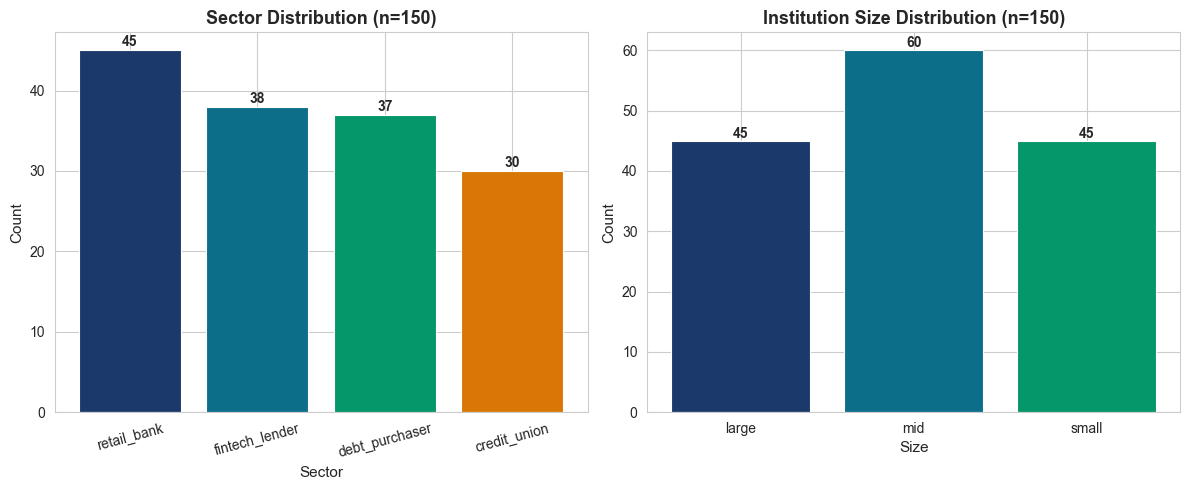

Sector counts:
sector
retail_bank       45
fintech_lender    38
debt_purchaser    37
credit_union      30

Size counts:
institution_size
large    45
mid      60
small    45


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sector distribution
sector_counts = df['sector'].value_counts()
axes[0].bar(sector_counts.index, sector_counts.values,
            color=PALETTE[:4], edgecolor='white', linewidth=0.8)
axes[0].set_title('Sector Distribution (n=150)', fontweight='bold')
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Count')
for i, v in enumerate(sector_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Size distribution
size_order  = ['large', 'mid', 'small']
size_counts = df['institution_size'].value_counts().reindex(size_order)
axes[1].bar(size_counts.index, size_counts.values,
            color=PALETTE[:3], edgecolor='white', linewidth=0.8)
axes[1].set_title('Institution Size Distribution (n=150)', fontweight='bold')
axes[1].set_xlabel('Size')
axes[1].set_ylabel('Count')
for i, v in enumerate(size_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()

# Save chart
charts_dir = PROJECT_ROOT / 'outputs' / 'charts'
charts_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(charts_dir / 'nb01_sector_size_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

print('Sector counts:')
print(sector_counts.to_string())
print()
print('Size counts:')
print(size_counts.to_string())

## Indicator Descriptive Statistics

In [5]:
desc = df[INDICATORS].describe().round(3)
print('=== INDICATOR DESCRIPTIVE STATISTICS ===')
print(desc.to_string())
print()

# Validation checks
assert df[INDICATORS].min().min() >= 1,  'ERROR: indicator below 1'
assert df[INDICATORS].max().max() <= 5,  'ERROR: indicator above 5'
assert (df[INDICATORS].dtypes == int).all(), 'ERROR: non-integer indicator'

mean_std = df[INDICATORS].mean().std()
assert mean_std > 0.05, f'ERROR: means too uniform (std={mean_std:.3f})'

print('✓ All values integers in [1, 5]')
print(f'✓ Indicator means are non-uniform (std={mean_std:.3f})')

=== INDICATOR DESCRIPTIVE STATISTICS ===
       data_quality  data_governance  data_integration  system_capability  ai_tooling  infrastructure_resilience  fca_alignment  consumer_duty  audit_trail  talent_readiness  change_management  leadership_commitment  bias_mitigation  explainability  accountability_structures
count       150.000          150.000           150.000            150.000     150.000                    150.000         150.00        150.000      150.000           150.000            150.000                150.000          150.000         150.000                    150.000
mean          3.260            3.440             3.373              3.347       3.367                      3.327           3.52          3.533        3.467             3.347              3.233                  3.380            3.333           3.333                      3.420
std           1.045            0.993             0.994              1.023       1.052                      1.026           0.91    

## Indicator Distribution Plot

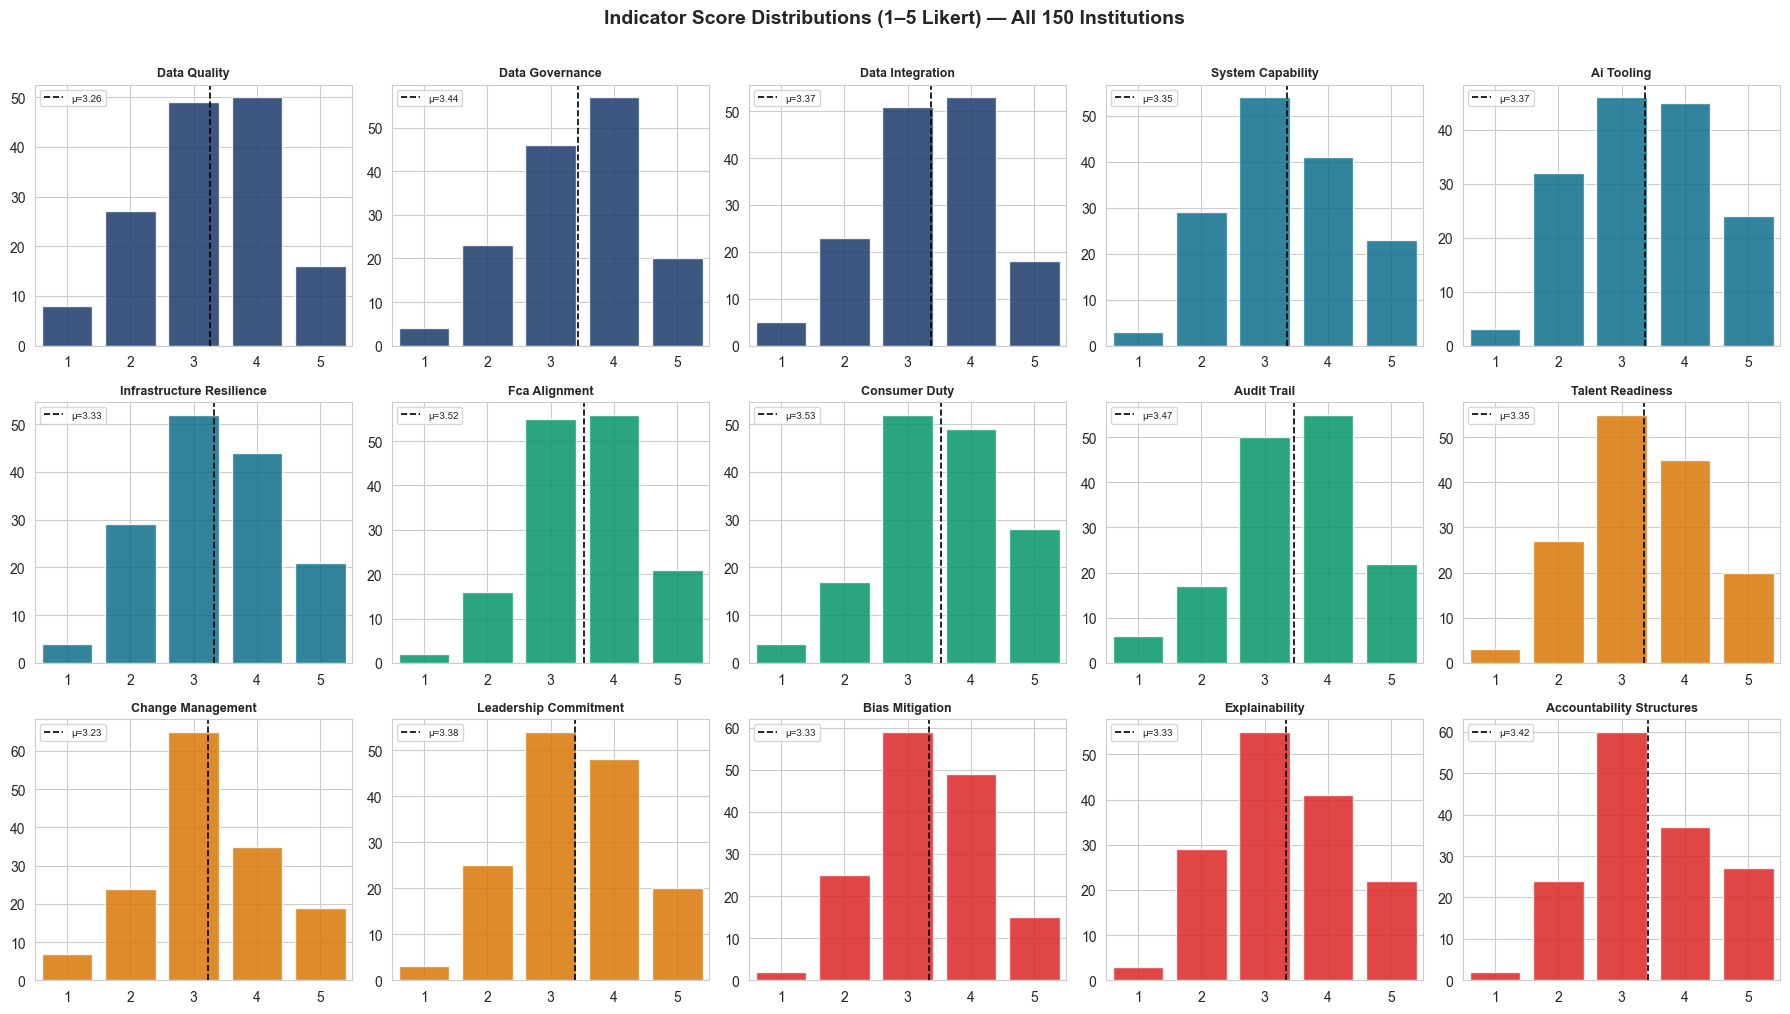

Chart saved: outputs/charts/nb01_indicator_distributions.png


In [6]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

dim_colours = {
    'data_quality': '#1B3A6B', 'data_governance': '#1B3A6B', 'data_integration': '#1B3A6B',
    'system_capability': '#0D6E8A', 'ai_tooling': '#0D6E8A', 'infrastructure_resilience': '#0D6E8A',
    'fca_alignment': '#059669', 'consumer_duty': '#059669', 'audit_trail': '#059669',
    'talent_readiness': '#D97706', 'change_management': '#D97706', 'leadership_commitment': '#D97706',
    'bias_mitigation': '#DC2626', 'explainability': '#DC2626', 'accountability_structures': '#DC2626',
}

for i, col in enumerate(INDICATORS):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values,
                color=dim_colours[col], alpha=0.85, edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[i].set_xticks([1, 2, 3, 4, 5])
    axes[i].set_xlim(0.5, 5.5)
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='black', linestyle='--', linewidth=1.2,
                    label=f'μ={mean_val:.2f}')
    axes[i].legend(fontsize=7, loc='upper left')

fig.suptitle('Indicator Score Distributions (1–5 Likert) — All 150 Institutions',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(charts_dir / 'nb01_indicator_distributions.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved: outputs/charts/nb01_indicator_distributions.png')

##  Sector-Level Mean Scores Heatmap

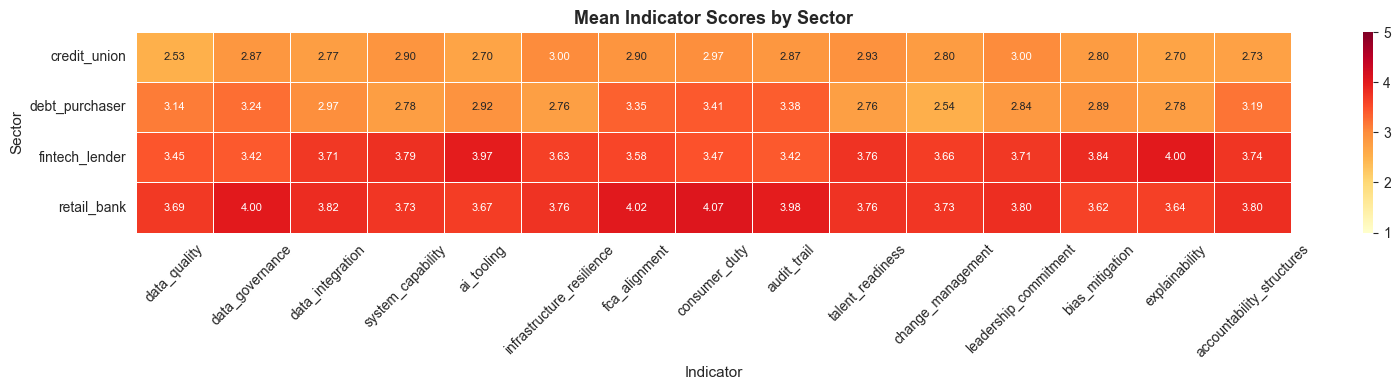

Sector means table:
                data_quality  data_governance  data_integration  system_capability  ai_tooling  infrastructure_resilience  fca_alignment  consumer_duty  audit_trail  talent_readiness  change_management  leadership_commitment  bias_mitigation  explainability  accountability_structures
sector                                                                                                                                                                                                                                                                                      
credit_union            2.53             2.87              2.77               2.90        2.70                       3.00           2.90           2.97         2.87              2.93               2.80                   3.00             2.80            2.70                       2.73
debt_purchaser          3.14             3.24              2.97               2.78        2.92                       2.76    

In [7]:
sector_means = df.groupby('sector')[INDICATORS].mean().round(2)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    sector_means,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    vmin=1, vmax=5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Mean Indicator Scores by Sector', fontweight='bold', fontsize=13)
ax.set_xlabel('Indicator')
ax.set_ylabel('Sector')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(charts_dir / 'nb01_sector_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

print('Sector means table:')
print(sector_means.to_string())

## Indicator Correlation Matrix

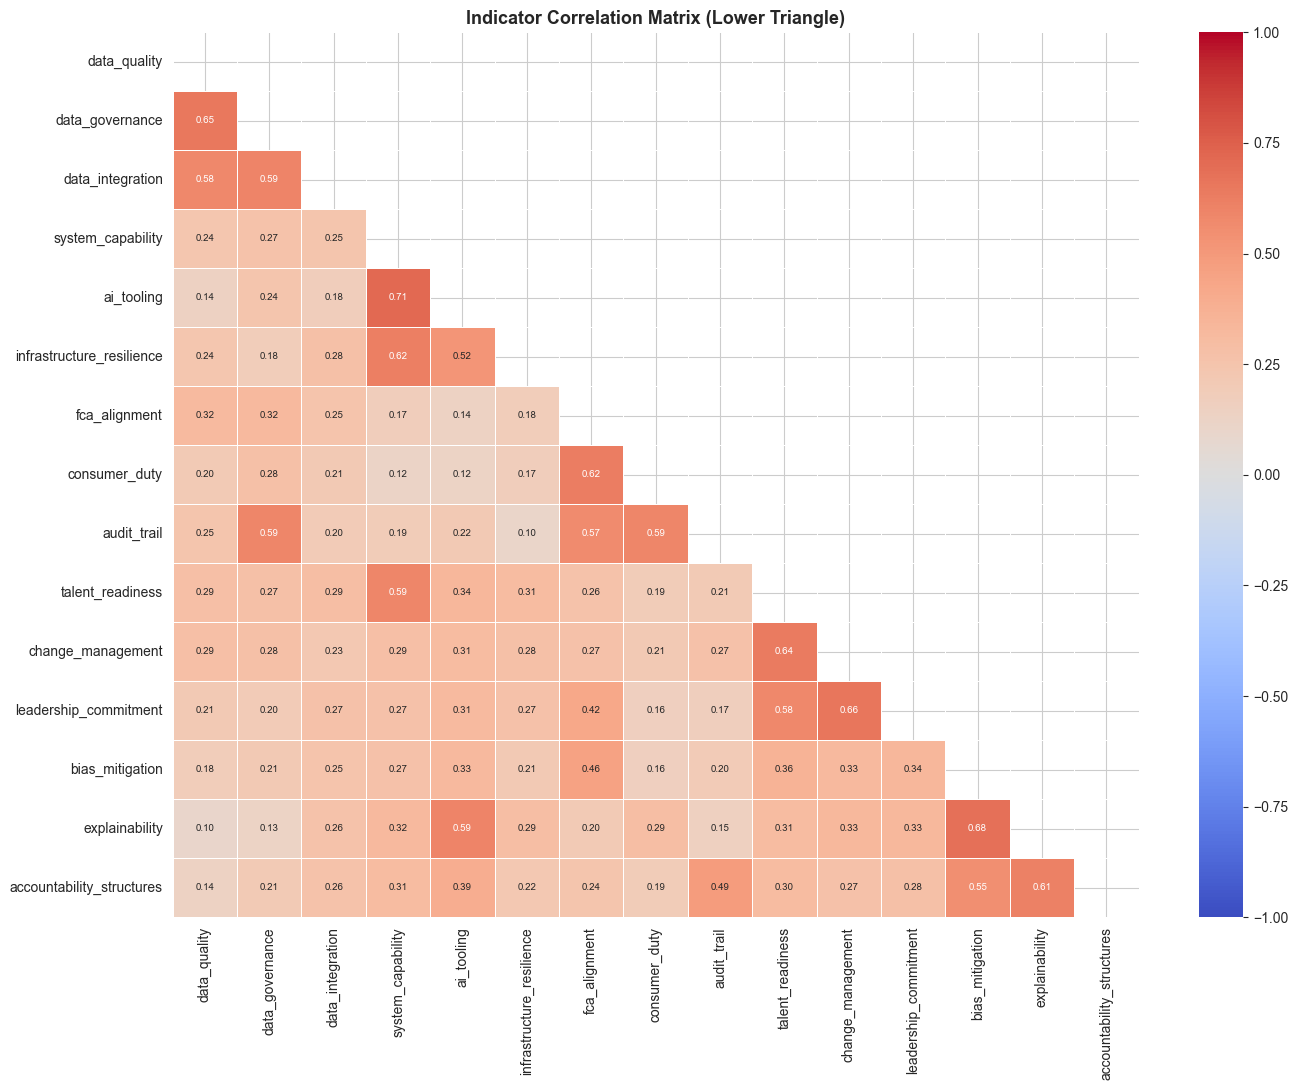

Key correlations (spec design targets):
  D3 regulatory pair            : 0.625
  D2 tech pair                  : 0.711
  Cross-dim governance          : 0.591
  D5 ethics pair                : 0.680


In [8]:
corr_matrix = df[INDICATORS].corr().round(3)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    ax=ax, annot_kws={'size': 7}
)
ax.set_title('Indicator Correlation Matrix (Lower Triangle)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(charts_dir / 'nb01_correlation_matrix.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Verify key correlations from spec
print('Key correlations (spec design targets):')
key_pairs = [
    ('fca_alignment',     'consumer_duty',    'D3 regulatory pair'),
    ('system_capability', 'ai_tooling',       'D2 tech pair'),
    ('data_governance',   'audit_trail',       'Cross-dim governance'),
    ('bias_mitigation',   'explainability',    'D5 ethics pair'),
]
for a, b, label in key_pairs:
    print(f'  {label:30s}: {corr_matrix.loc[a, b]:.3f}')

## Size-Based Score Differences

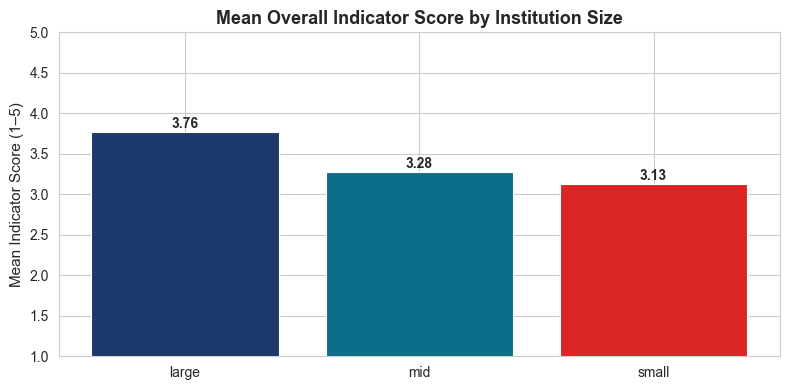

Overall mean score by size:
institution_size
large    3.764
mid      3.279
small    3.126

✓ large institutions score higher than small (size effect confirmed)


In [9]:
size_means = df.groupby('institution_size')[INDICATORS].mean()
size_order = ['large', 'mid', 'small']
size_means = size_means.reindex(size_order)

# Overall mean per size group
size_overall = size_means.mean(axis=1).round(3)

fig, ax = plt.subplots(figsize=(8, 4))
colours = ['#1B3A6B', '#0D6E8A', '#DC2626']
bars = ax.bar(size_order, size_overall.values, color=colours,
              edgecolor='white', linewidth=0.8)
ax.set_title('Mean Overall Indicator Score by Institution Size',
             fontweight='bold')
ax.set_ylabel('Mean Indicator Score (1–5)')
ax.set_ylim(1, 5)
for bar, val in zip(bars, size_overall.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05, f'{val:.2f}',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(charts_dir / 'nb01_size_score_differences.png',
            dpi=300, bbox_inches='tight')
plt.show()

print('Overall mean score by size:')
print(size_overall.to_string())

# Validate: large > small
assert size_overall['large'] > size_overall['small'], \
    'ERROR: large institutions should score higher than small'
print('\n✓ large institutions score higher than small (size effect confirmed)')

## Missing Values & Data Quality Check

In [10]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('✓ No missing values in any column')
else:
    print(missing[missing > 0])

print()
print('=== DUPLICATE ROWS ===')
dupes = df.duplicated().sum()
print(f'✓ Duplicate rows: {dupes}')

print()
print('=== INSTITUTION_ID UNIQUENESS ===')
n_unique = df['institution_id'].nunique()
print(f'✓ Unique IDs: {n_unique} / {len(df)}')
assert n_unique == len(df), 'ERROR: duplicate institution IDs'

print()
print('=== INDICATOR RANGE CHECK ===')
for col in INDICATORS:
    lo, hi = df[col].min(), df[col].max()
    status = '✓' if lo >= 1 and hi <= 5 else '✗'
    print(f'  {status} {col:35s} min={lo}  max={hi}')

=== MISSING VALUES ===
✓ No missing values in any column

=== DUPLICATE ROWS ===
✓ Duplicate rows: 0

=== INSTITUTION_ID UNIQUENESS ===
✓ Unique IDs: 150 / 150

=== INDICATOR RANGE CHECK ===
  ✓ data_quality                        min=1  max=5
  ✓ data_governance                     min=1  max=5
  ✓ data_integration                    min=1  max=5
  ✓ system_capability                   min=1  max=5
  ✓ ai_tooling                          min=1  max=5
  ✓ infrastructure_resilience           min=1  max=5
  ✓ fca_alignment                       min=1  max=5
  ✓ consumer_duty                       min=1  max=5
  ✓ audit_trail                         min=1  max=5
  ✓ talent_readiness                    min=1  max=5
  ✓ change_management                   min=1  max=5
  ✓ leadership_commitment               min=1  max=5
  ✓ bias_mitigation                     min=1  max=5
  ✓ explainability                      min=1  max=5
  ✓ accountability_structures           min=1  max=5


## Generation Assumptions Documentation

In [11]:
assumptions = """
GENERATION ASSUMPTIONS — Notebook 01
======================================

1. SYNTHETIC DATA ONLY
   No real institutional data was used. All 150 profiles are computer-generated.
   No real institution names, financials, or identifiable characteristics appear.

2. SECTOR-SPECIFIC BASE MEANS
   Each sector has a distinct per-indicator mean vector (not a uniform global mean).
   This encodes realistic sector patterns:
     - retail_bank:     highest D3 regulatory compliance (FCA oversight most mature)
     - fintech_lender:  highest D2 technological maturity (born-digital advantage)
     - debt_purchaser:  average across all dimensions
     - credit_union:    lowest overall (resource-constrained, limited AI exposure)

3. SIZE ADJUSTMENT
   Institution size shifts the mean uniformly across all indicators:
     large (+0.4), mid (+0.1), small (-0.2)
   Rationale: larger institutions have more resources for AI investment.

4. CORRELATION STRUCTURE
   A 15x15 covariance matrix injects 22 realistic cross-indicator correlations.
   Key design correlations:
     - fca_alignment <-> consumer_duty       : ~0.70 (same regulatory domain)
     - system_capability <-> ai_tooling      : ~0.75 (co-evolving capabilities)
     - data_governance <-> audit_trail       : ~0.55 (governance enables audit)
     - bias_mitigation <-> explainability    : ~0.70 (ethical AI pair)
   The matrix is forced positive semi-definite via eigenvalue clipping.

5. REPRODUCIBILITY
   Random seed 42 is set globally (numpy, random, Faker) before generation.
   Any run with seed=42 produces bit-for-bit identical output.

6. LIKERT CLIPPING
   Continuous samples from the multivariate normal are rounded and hard-clipped
   to integer range [1, 5]. This slightly compresses the tails but preserves
   the correlation structure in the interior of the distribution.

7. LIMITATIONS
   - 150 records is sufficient for XGBoost but limits statistical power for
     subgroup analyses (e.g. sector × size interactions).
   - Correlation structure is design-based, not empirically derived from real data.
   - Sector base means are informed estimates, not calibrated from survey data.
     CVI expert validation (Step 14) will provide empirical grounding.
"""
print(assumptions)

# Save assumptions to outputs
reports_dir = PROJECT_ROOT / 'outputs' / 'reports'
reports_dir.mkdir(parents=True, exist_ok=True)
with open(reports_dir / 'nb01_generation_assumptions.txt', 'w') as f:
    f.write(assumptions)
print('Assumptions saved to outputs/reports/nb01_generation_assumptions.txt')


GENERATION ASSUMPTIONS — Notebook 01

1. SYNTHETIC DATA ONLY
   No real institutional data was used. All 150 profiles are computer-generated.
   No real institution names, financials, or identifiable characteristics appear.

2. SECTOR-SPECIFIC BASE MEANS
   Each sector has a distinct per-indicator mean vector (not a uniform global mean).
   This encodes realistic sector patterns:
     - retail_bank:     highest D3 regulatory compliance (FCA oversight most mature)
     - fintech_lender:  highest D2 technological maturity (born-digital advantage)
     - debt_purchaser:  average across all dimensions
     - credit_union:    lowest overall (resource-constrained, limited AI exposure)

3. SIZE ADJUSTMENT
   Institution size shifts the mean uniformly across all indicators:
     large (+0.4), mid (+0.1), small (-0.2)
   Rationale: larger institutions have more resources for AI investment.

4. CORRELATION STRUCTURE
   A 15x15 covariance matrix injects 22 realistic cross-indicator correlations.

## Final Validation & Completion Check

In [12]:
print('=== NOTEBOOK 01 COMPLETION CHECKS ===')
print()

checks = [
    ('150 institutions generated',        len(df) == 150),
    ('CSV file exists on disk',           OUTPUT_PATH.exists()),
    ('All 19 columns present',            all(c in df.columns for c in
                                             ['institution_id','institution_name',
                                              'sector','institution_size'] + INDICATORS)),
    ('All indicators integers in [1,5]',  df[INDICATORS].min().min() >= 1
                                          and df[INDICATORS].max().max() <= 5
                                          and (df[INDICATORS].dtypes == int).all()),
    ('4 sectors present',                 df['sector'].nunique() == 4),
    ('3 sizes present',                   df['institution_size'].nunique() == 3),
    ('No missing values',                 df.isnull().sum().sum() == 0),
    ('No duplicate IDs',                  df['institution_id'].nunique() == 150),
    ('Means are non-uniform (not noise)', df[INDICATORS].mean().std() > 0.05),
    ('Sector effect: retail > credit D3', (df[df.sector=='retail_bank']['fca_alignment'].mean() >
                                           df[df.sector=='credit_union']['fca_alignment'].mean())),
    ('Size effect: large > small',        (df[df.institution_size=='large'][INDICATORS].mean().mean() >
                                           df[df.institution_size=='small'][INDICATORS].mean().mean())),
]

all_passed = True
for label, result in checks:
    status = '✓ PASS' if result else '✗ FAIL'
    if not result:
        all_passed = False
    print(f'  {status}  {label}')

print()
if all_passed:
    print('ALL CHECKS PASSED — Notebook 01 complete.')
    print('Ready for Notebook 02 (Scoring Engine).')
else:
    print('ONE OR MORE CHECKS FAILED — review output above.')
    raise AssertionError('Notebook 01 completion checks failed.')

=== NOTEBOOK 01 COMPLETION CHECKS ===

  ✓ PASS  150 institutions generated
  ✓ PASS  CSV file exists on disk
  ✓ PASS  All 19 columns present
  ✓ PASS  All indicators integers in [1,5]
  ✓ PASS  4 sectors present
  ✓ PASS  3 sizes present
  ✓ PASS  No missing values
  ✓ PASS  No duplicate IDs
  ✓ PASS  Means are non-uniform (not noise)
  ✓ PASS  Sector effect: retail > credit D3
  ✓ PASS  Size effect: large > small

ALL CHECKS PASSED — Notebook 01 complete.
Ready for Notebook 02 (Scoring Engine).
